1. Import the Libraries

In [30]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

2. Load Data

In [31]:
col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"
]

train_df = pd.read_csv("../data/nsl-kdd/KDDTrain+.txt", names=col_names)
test_df = pd.read_csv("../data/nsl-kdd/KDDTest-21.txt", names=col_names)

print("---Training Data---")
print(f"Shape: {train_df.shape}")
print("\n---Test Data---")
print(f"Shape: {test_df.shape}")


---Training Data---
Shape: (125973, 43)

---Test Data---
Shape: (11850, 43)


3. Drop unused column

In [32]:
train_df.drop(['difficulty'], axis=1, inplace=True)
test_df.drop(['difficulty'], axis=1, inplace=True)

4. Encode categorical variables

In [33]:
categorical_cols = ['protocol_type', 'service', 'flag']
train_df = pd.get_dummies(train_df, columns=categorical_cols)
test_df = pd.get_dummies(test_df, columns=categorical_cols)

5. Align train and test columns

In [41]:
train_cols = train_df.columns
test_cols = test_df.columns
for c in (set(train_cols) - set(test_cols)):
    test_df[c] = 0
for c in (set(test_cols) - set(train_cols)):
    train_df[c] = 0

# Reorder columns to match
test_df = test_df[train_df.columns]
print(f"Shape of training data after encoding: {train_df.shape}")
print(f"Shape of testing data after encoding: {test_df.shape}")

Shape of training data after encoding: (125973, 123)
Shape of testing data after encoding: (11850, 123)


6. Features & labels

In [35]:
X = train_df.drop(['label'], axis=1)
y = train_df['label']

X_test_final = test_df.drop(['label'], axis=1)
y_test_final = test_df['label']

7. Encode labels into integers (multi-classs)

In [36]:
le = LabelEncoder()
all_labels = pd.concat([train_df['label'], test_df['label']])  # combine labels
le.fit(all_labels)

y = le.transform(train_df['label'])
y_test_final = le.transform(test_df['label'])

8. Scaling

In [37]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_test_final_scaled = scaler.transform(X_test_final)

9. Train/Validation Split

In [38]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

10. Models

In [39]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Linear SVM": LinearSVC(random_state=42, max_iter=2000)
}

11. Training & Evaluation


===== Logistic Regression =====


c:\Users\khush\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in l

Validation Accuracy: 0.8479460210359199
Validation Report:
                  precision    recall  f1-score   support

           back       0.00      0.00      0.00       191
buffer_overflow       0.00      0.00      0.00         6
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       0.00      0.00      0.00        11
           imap       0.00      0.00      0.00         2
        ipsweep       0.00      0.00      0.00       720
           land       0.00      0.00      0.00         4
     loadmodule       0.00      0.00      0.00         2
       multihop       0.00      0.00      0.00         1
        neptune       0.81      0.99      0.89      8243
           nmap       0.00      0.00      0.00       299
         normal       0.87      0.96      0.91     13469
            phf       0.00      0.00      0.00         1
            pod       0.00      0.00      0.00        40
      portsweep       0.70      0.25      0.37       586
        rootkit       0.00 

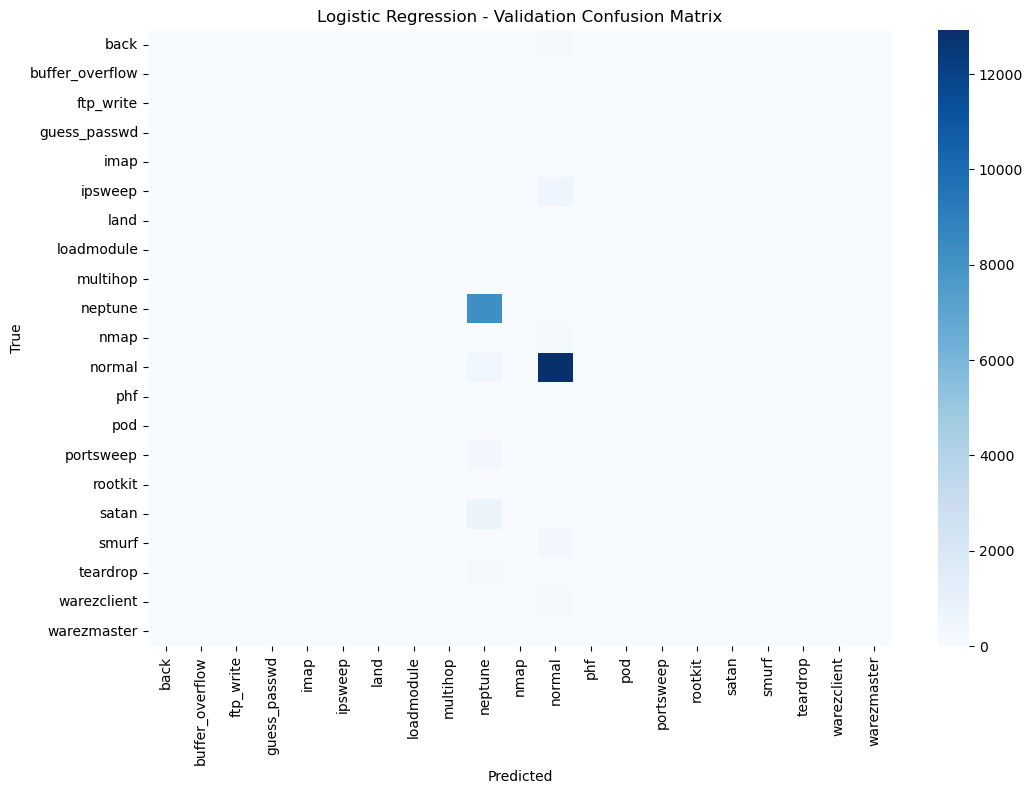

c:\Users\khush\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no p

Test Accuracy: 0.23468354430379748
Test Report:
                  precision    recall  f1-score   support

        apache2       0.00      0.00      0.00       737
           back       0.00      0.00      0.00       359
buffer_overflow       0.00      0.00      0.00        20
      ftp_write       0.00      0.00      0.00         3
   guess_passwd       0.00      0.00      0.00      1231
     httptunnel       0.00      0.00      0.00       133
           imap       0.00      0.00      0.00         1
        ipsweep       0.00      0.00      0.00       141
           land       0.00      0.00      0.00         7
     loadmodule       0.00      0.00      0.00         2
       mailbomb       0.00      0.00      0.00       293
          mscan       0.00      0.00      0.00       996
       multihop       0.00      0.00      0.00        18
          named       0.00      0.00      0.00        17
        neptune       0.28      0.97      0.43      1579
           nmap       0.00      0.00  

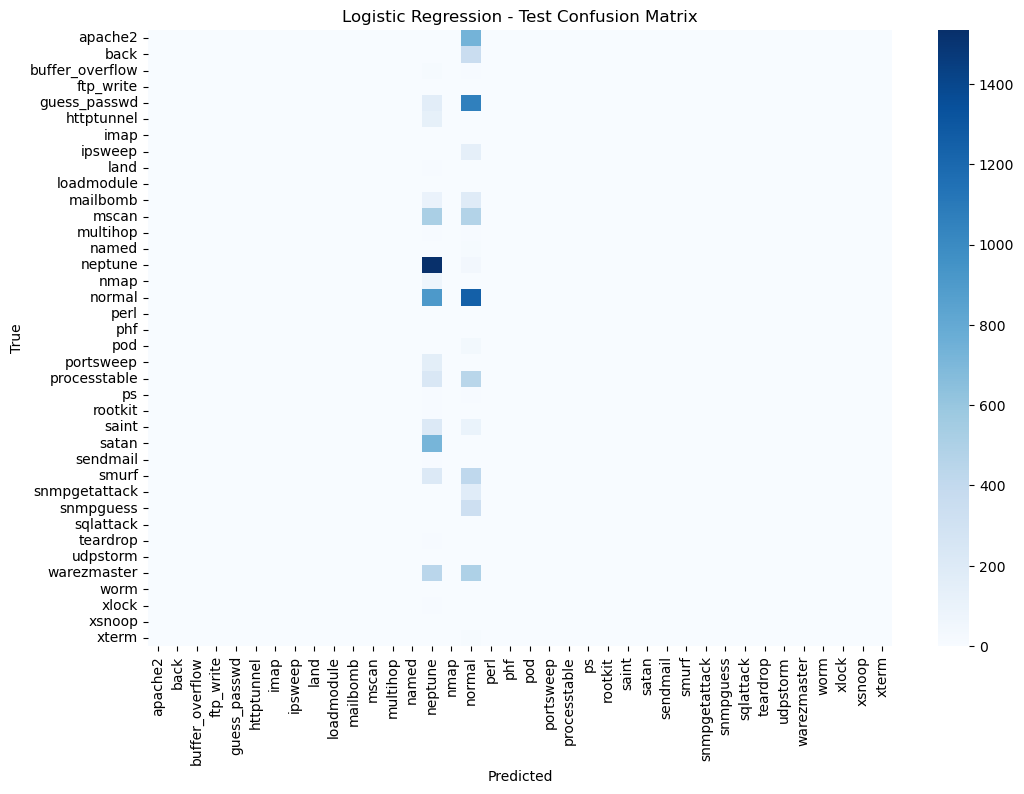


===== Random Forest =====
Validation Accuracy: 0.9983726929946418
Validation Report:
                  precision    recall  f1-score   support

           back       0.99      1.00      1.00       191
buffer_overflow       1.00      0.83      0.91         6
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       1.00      1.00      1.00        11
           imap       1.00      1.00      1.00         2
        ipsweep       1.00      1.00      1.00       720
           land       0.75      0.75      0.75         4
     loadmodule       0.00      0.00      0.00         2
       multihop       0.00      0.00      0.00         1
        neptune       1.00      1.00      1.00      8243
           nmap       0.99      0.99      0.99       299
         normal       1.00      1.00      1.00     13469
            phf       0.00      0.00      0.00         1
            pod       1.00      0.97      0.99        40
      portsweep       1.00      0.99      0.99       586


c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


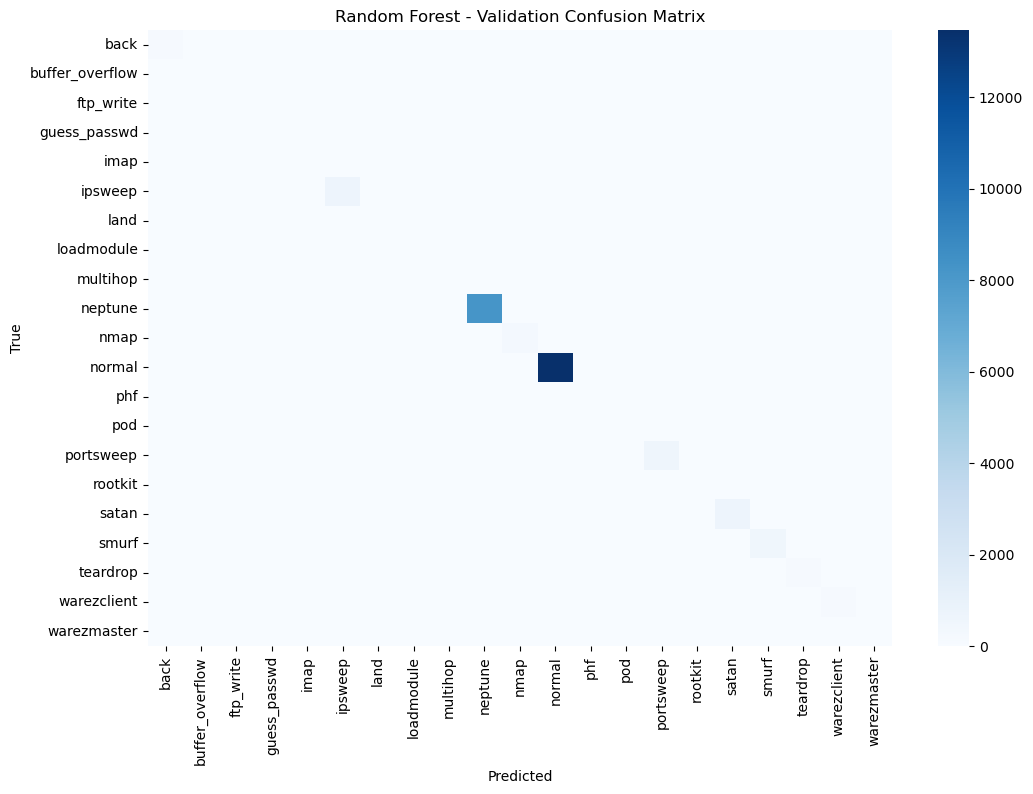

c:\Users\khush\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Test Accuracy: 0.3816033755274262
Test Report:
                  precision    recall  f1-score   support

        apache2       0.00      0.00      0.00       737
           back       0.00      0.00      0.00       359
buffer_overflow       0.00      0.00      0.00        20
      ftp_write       0.00      0.00      0.00         3
   guess_passwd       0.00      0.00      0.00      1231
     httptunnel       0.00      0.00      0.00       133
           imap       0.00      0.00      0.00         1
        ipsweep       0.74      0.99      0.84       141
           land       1.00      0.14      0.25         7
     loadmodule       0.00      0.00      0.00         2
       mailbomb       0.00      0.00      0.00       293
          mscan       0.00      0.00      0.00       996
       multihop       0.00      0.00      0.00        18
          named       0.00      0.00      0.00        17
        neptune       0.88      0.97      0.92      1579
           nmap       0.31      1.00   

c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


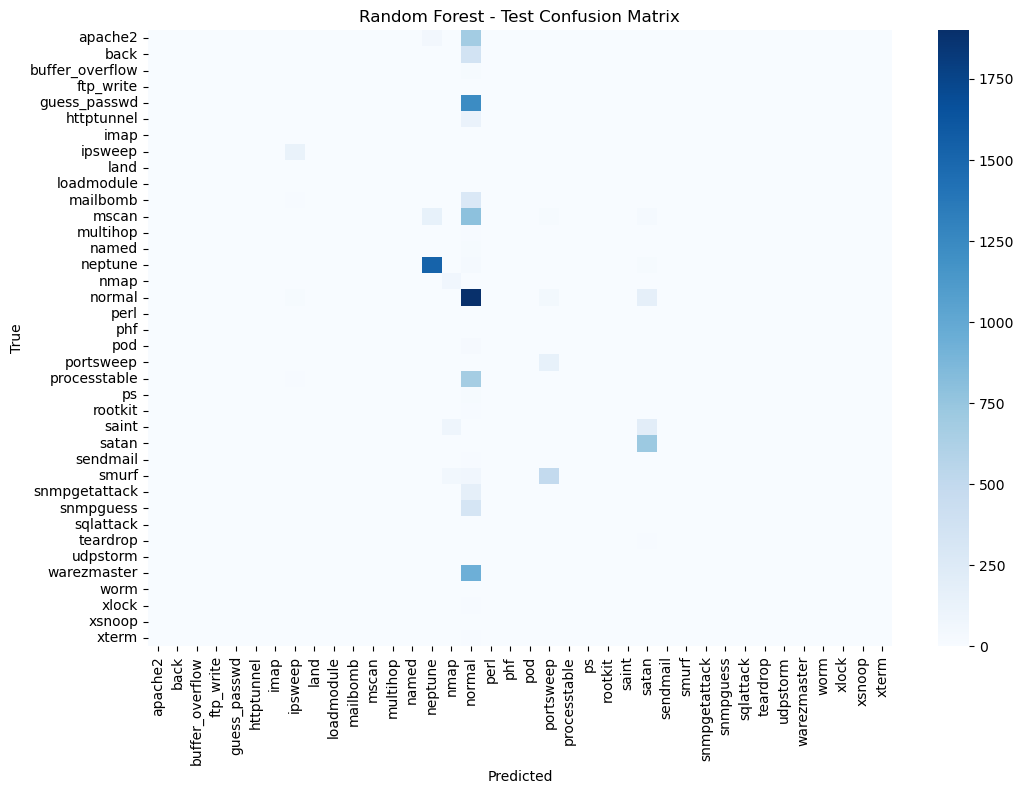


===== Linear SVM =====


c:\Users\khush\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted sam

Validation Accuracy: 0.7799960309585235
Validation Report:
                  precision    recall  f1-score   support

           back       0.00      0.00      0.00       191
buffer_overflow       0.00      0.00      0.00         6
      ftp_write       0.00      0.00      0.00         2
   guess_passwd       0.34      0.91      0.50        11
           imap       0.25      1.00      0.40         2
        ipsweep       0.97      0.94      0.95       720
           land       0.75      0.75      0.75         4
     loadmodule       0.00      0.00      0.00         2
       multihop       0.00      0.00      0.00         1
        neptune       0.68      1.00      0.81      8243
           nmap       0.22      0.68      0.34       299
         normal       0.97      0.66      0.78     13469
            phf       0.00      0.00      0.00         1
            pod       0.60      0.15      0.24        40
      portsweep       1.00      0.57      0.73       586
        rootkit       0.00 

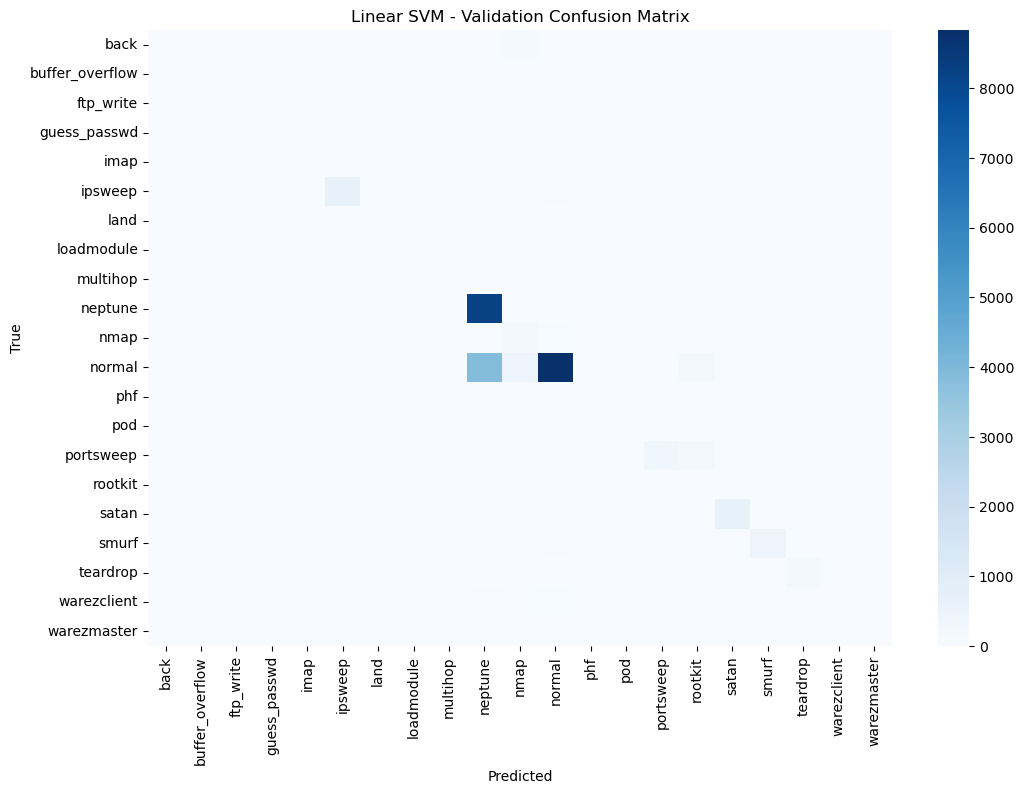

c:\Users\khush\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\khush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted 

Test Accuracy: 0.2019409282700422
Test Report:
                  precision    recall  f1-score   support

        apache2       0.00      0.00      0.00       737
           back       0.00      0.00      0.00       359
buffer_overflow       0.00      0.00      0.00        20
      ftp_write       0.00      0.67      0.01         3
   guess_passwd       0.00      0.00      0.00      1231
     httptunnel       0.00      0.00      0.00       133
           imap       0.00      0.00      0.00         1
        ipsweep       0.06      0.99      0.11       141
           land       0.01      0.71      0.02         7
     loadmodule       0.00      0.00      0.00         2
       mailbomb       0.00      0.00      0.00       293
          mscan       0.00      0.00      0.00       996
       multihop       0.00      0.00      0.00        18
          named       0.00      0.00      0.00        17
        neptune       0.71      0.52      0.60      1579
           nmap       0.14      0.99   

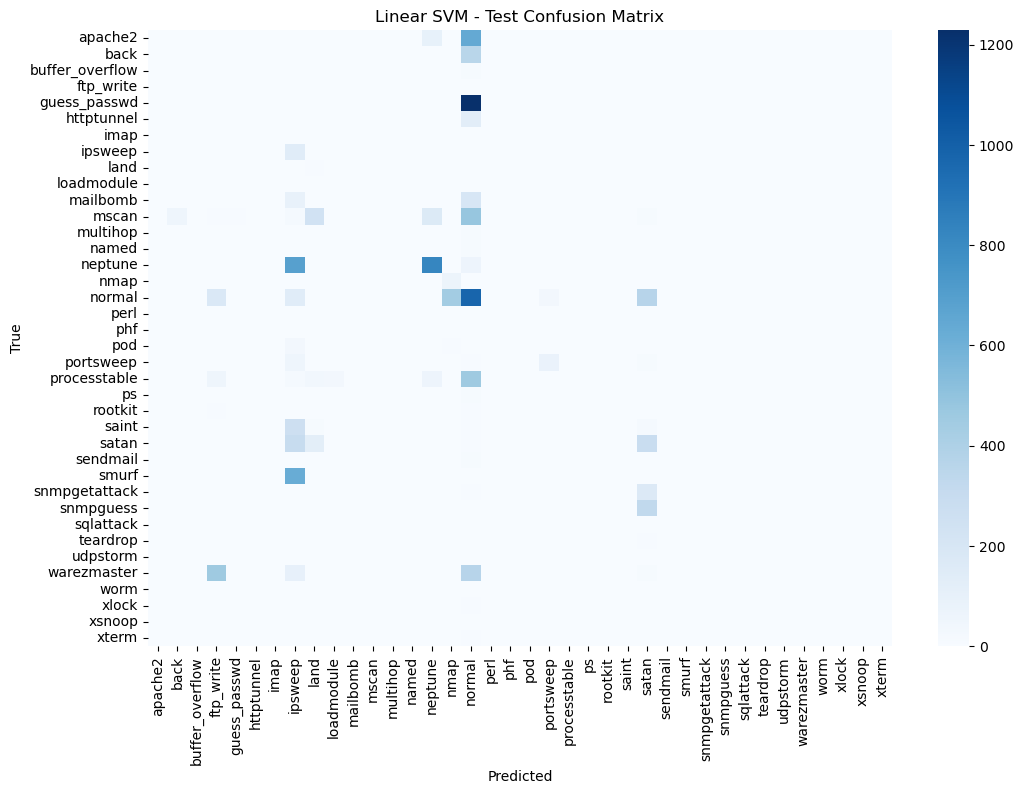

In [40]:
for name, model in models.items():
    print(f"\n===== {name} =====")
    model.fit(X_train, y_train)

    # --- Validation Performance ---
    y_val_pred = model.predict(X_val)
    val_classes = np.unique(y_val)
    val_class_names = le.inverse_transform(val_classes).astype(str).tolist()

    print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
    print("Validation Report:\n",
          classification_report(y_val, y_val_pred, labels=val_classes, target_names=val_class_names))

    val_cm = confusion_matrix(y_val, y_val_pred, labels=val_classes)
    plt.figure(figsize=(12, 8))
    sns.heatmap(val_cm, cmap="Blues", xticklabels=val_class_names, yticklabels=val_class_names)
    plt.title(f"{name} - Validation Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # --- Test Performance ---
    y_test_pred = model.predict(X_test_final_scaled)
    test_classes = np.unique(y_test_final)
    test_class_names = le.inverse_transform(test_classes).astype(str).tolist()

    print("Test Accuracy:", accuracy_score(y_test_final, y_test_pred))
    print("Test Report:\n",
          classification_report(y_test_final, y_test_pred, labels=test_classes, target_names=test_class_names))

    test_cm = confusion_matrix(y_test_final, y_test_pred, labels=test_classes)
    plt.figure(figsize=(12, 8))
    sns.heatmap(test_cm, cmap="Blues", xticklabels=test_class_names, yticklabels=test_class_names)
    plt.title(f"{name} - Test Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()